In [11]:
import os
print(os.listdir('/data/gravwav/lopezm/Projects/EuCAIF/sage/'))
import sys
import matplotlib.pyplot as plt
import torch

# 1. Unload cached 'sage' module if Jupyter stored a broken reference
for module in list(sys.modules.keys()):
    if module == 'sage' or module.startswith('sage.'):
        del sys.modules[module]

sys.path.insert(0, '/data/gravwav/lopezm/Projects/EuCAIF/sage/')

from sage.data.waveform import read_from_config, ConstantProjection, IMRPhenomPv2
from sage.data.waveform import HalfNorm

detectors = ["H1", "L1"]
batch_size = 10
# 1. Minimal Config Registration
class DummyCFG:
    export_dir = "/data/gravwav/lopezm/Projects/EuCAIF/eucaif_gw/sage"
    batch_size = batch_size
    device = "cuda:0" if torch.cuda.is_available() else "cpu"
    dtype = torch.float32
    detectors = detectors
    class_balance = 0.5
    do_point_estimate = ["tc", "mchirp", "ra", "dec"]

class DummyDataCFG:
    sample_rate = 2048.0  # Hz
    noise_low_frequency_cutoff = 15.0  # Hz
    signal_low_frequency_cutoff = 20.0  # Hz
    sample_length_in_s = 4.0  # seconds
    padded_length_in_s = 8.0  # seconds
    padding_length_in_s = 8.0  # seconds
    delta_f = 1.0 / sample_length_in_s  # Hz
    corrupted_length = 2.0 # seconds

from sage.core.config import register_configs
from sage.core.base_classes import BaseConfig, BaseDataConfig
cfg = BaseConfig(DummyCFG())
data_cfg = BaseDataConfig(DummyDataCFG())
register_configs(DummyCFG(), DummyDataCFG())


['.git', '.github', '.gitignore', '.readthedocs.yaml', 'CHANGELOG.md', 'CITATION.cff', 'CONTRIBUTING.md', 'ELI5', 'LICENSE', 'README.md', 'docs', 'notebooks', 'pyproject.toml', 'repro', 'requirements.txt', 'runs', 'sage', 'tests', 'utils']


In [2]:
from sage.data.noise import sample_synthetic_noise
noise_batch, asd_used, freqs_used = sample_synthetic_noise(4.0, ["aLIGOZeroDetHighPower", "aLIGOZeroDetHighPower"], detectors=["H1", "L1"], batch=batch_size, is_asd=True)  
negative_batch, positive_batch = noise_batch[:5], noise_batch[5:]
negative_batch.shape, positive_batch.shape

/data/gravwav/lopezm/cmb_env/miniforge3/envs/eucaif/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


torch.Size([2, 6145]) torch.Size([6145])


(torch.Size([5, 2, 8192]), torch.Size([5, 2, 8192]))

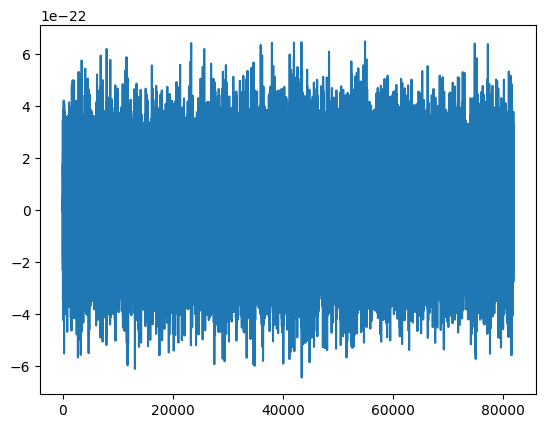

In [89]:
x[:, 0].flatten().shape
plt.plot(x[:, 0].flatten())

In [101]:
from sage.data.waveform import read_from_config, ConstantProjection, IMRPhenomPv2
from sage.data.waveform import HalfNorm
from sage.data.waveform.snr import OptimalSNRRescaler

# Parameter prior from the YAML config
param_sampler = read_from_config("./sage_eucaif_waveform.yaml", seed=150914)

# ConstantProjection applies time-independent antenna-pattern weighting
# for each detector — no manual RA/dec/polarisation passing needed
waveform_project = ConstantProjection()

signal_sampler = IMRPhenomPv2(param_sampler, waveform_project)
signal_data, signal_targets = signal_sampler()
signal_data.shape, signal_targets.shape
positive_batch = positive_batch + signal_data[:, :, :positive_batch.shape[2]]
positive_batch.shape



torch.Size([5, 2, 8192])

/data/gravwav/lopezm/cmb_env/miniforge3/envs/eucaif/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/data/gravwav/lopezm/cmb_env/miniforge3/envs/eucaif/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


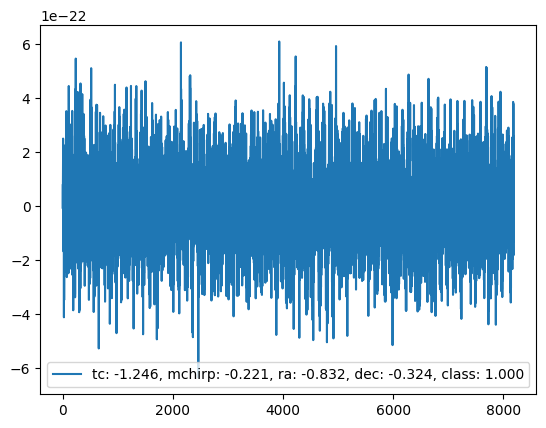

In [94]:
plt.plot(positive_batch[1, 0].flatten())
target_names = ["tc", "mchirp", "ra", "dec", "class"]
target_text = ", ".join(
    f"{name}: {value.item():.3f}"
    for name, value in zip(target_names, signal_targets[1])
)   
plt.legend([target_text])

In [13]:
from sage.dsp.whiten import FiducialWhitening

psd_used = asd_used.double()**2
whitener = FiducialWhitening(
    psd_used[0],
    seq_len=int(data_cfg.sample_rate * (data_cfg.sample_length_in_s + 2 * data_cfg.padding_length_in_s)),
    sample_rate=data_cfg.sample_rate,
    device=cfg.device,
    corrupted_length=data_cfg.corrupted_length,
)

#whitened = whitener.whiten(noisy_signal)

TypeError: FiducialWhitening.__init__() takes 1 positional argument but 2 were given

tensor([0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 5.3031e-24, 5.3036e-24,
        0.0000e+00])


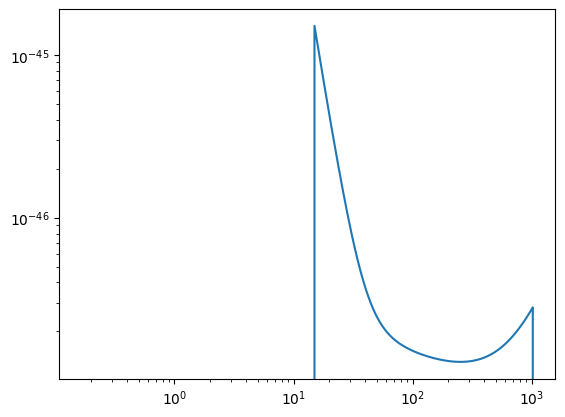

In [8]:
print(asd_used[0])
asd_used[0].shape, (asd_used.double()[0]**2).shape
plt.loglog(freqs_used, asd_used.double()[0]**2)

In [15]:
psd_used[0].shape

torch.Size([6145])